# Thermal State Preparation of the Schwinger Model
**Ultimate Goal**: Prepare a thermal state
$$e^{-\beta H} / Z$$
approximately for a large system.

## Basic Imports
From Mark Rudner's *Implementations in Quantum Information* course.

In [1]:
# For circuit setup
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

# For transpilation
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# For backends and running circuits via Sampler
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService

# For math and data analysis
import math
import numpy as np
from numpy import pi
from matplotlib import pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

## Backend Setup

In [2]:
# Set up a backend that runs a noiseless simulator
from qiskit_aer import AerSimulator
backend = AerSimulator()

# from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
# backend = FakeMarrakesh()

## Transpiler Setup

In [3]:
# Create the "pass manager" that will perform the transpilation
pm = generate_preset_pass_manager(backend=backend, optimization_level=0)

## Schwinger Hamiltonian
The following function creates the Schwinger model Hamiltonian as a SparsePauliOp.
$$H = H_{kin} + H_{mass} + H_{elec}$$
where
$$H_{kin} \equiv \frac{1}{2a} \sum_{n = 0}^{L - 2} (\sigma_n^{+} \sigma_{n+1}^{-} + \sigma_{n+1}^{+} \sigma_n^{-})$$
$$H_{mass} \equiv m \sum_{n=0}^{L-1} O_n, O_n \equiv (-1)^n \frac{\sigma_n^z + 1}{2a}$$
$$H_{elec} \equiv \frac{a}{2} \sum_{n=0}^L E_n^2, E_n \equiv e(l_0 + \frac{1}{2} \sum_{j=0}^{n-1}(\sigma_j^z + (-1)^j)$$

a: lattice space

n: index of lattice position $x = na$

L: number of fermion sites = 2 * N

N: number of physical sites in the stagger fermion formulation

$\sigma^{\pm} = (\sigma_x \pm i\sigma_y)/2)$: creation/annihilation operators

We set $l_0 = 0$.

In [4]:
def get_schwinger_hamiltonian(L: int, m: float, e: float, a: float, include_shifts: bool = True) -> SparsePauliOp:
    if L <= 0:
        raise ValueError("L must be >= 1.")
    if a == 0:
        raise ValueError("a must be nonzero.")
    
    terms = []

    # Kinetic term
    ## H_kin = sum_{i=0}^{L-2} (1/(4a)) (X_i X_{i+1} + Y_i Y_{i+1})
    kin_coeff = 1.0 / (4.0 * a)
    for i in range(L - 1):
        terms.append(("XX", [i, i + 1], kin_coeff))
        terms.append(("YY", [i, i + 1], kin_coeff))

    # Mass term
    ## H_mass = sum_i m * (-1)^i * (Z_i + I)/(2a)
    for i in range(L):
        coeff = m * ((-1) ** i) / (2.0 * a)
        terms.append(("Z", [i], coeff))
        if include_shifts: # global energy shift
            terms.append(("I", [0], coeff))

    # Electric term
    ## E_i = (e/2) (S_i + C_i),  S_i = sum_{j<i} Z_j,  C_i = sum_{j<i} (-1)^j
    ## E_i^2 = (e^2/4) [ S_i^2 + 2 C_i S_i + C_i^2 ]
    ## S_i^2 = i*I + 2 sum_{j<k<i} Z_j Z_k
    base_I = (a / 2.0) * (e**2 / 4.0)
    zz_coeff = (a * e**2) / 4.0
    z_per_link_unit = (a * e**2) / 4.0

    for i in range(1, L + 1):
        # C_i = sum_{j=0}^{i-1} (-1)^j = 1 if i is odd else 0
        C = i % 2

        # Identity from i*I + C^2*I
        if include_shifts:
            terms.append(("I", [0], base_I * (i + C))) # since C^2 = C for C in {0, 1}

        # linear Z terms: (a/2)*(e^2/4)*(2 C) * sum_{j<i} Z_j = (a e^2/4)*C * sum_{j<i} Z_j
        if C == 1:
            for j in range(i):
                terms.append(("Z", [j], z_per_link_unit))

        # ZZ terms: (a/2)*(e^2/4)*(2) * sum_{j<k<i} Z_j Z_k = (a e^2/4) * sum_{j<k<i} Z_j Z_k
        for j in range(i):
            for k in range(j + 1, i):
                terms.append(("ZZ", [j, k], zz_coeff))

    H = SparsePauliOp.from_sparse_list(terms, num_qubits = L)
    return H.simplify()

### Checking Hamiltonian construction

In [5]:
# Parameters
L = 6
a = 1.0
m = 0.5
e = 1.0

H = get_schwinger_hamiltonian(L, m, e, a)
H_dense = H.to_matrix()

vals_all = np.linalg.eigvals(H_dense)
vals_all = np.real_if_close(vals_all, tol=1e5) # removes tiny imaginary parts
vals_all = np.asarray(vals_all, dtype = np.complex128)
vals_all

array([ 2.20385406+0.j,  3.17706422+0.j,  4.09554717+0.j,  4.41861399+0.j,
        5.77348826+0.j,  6.83143231+0.j, 12.07124027+0.j,  7.8564808 +0.j,
        8.77915666+0.j,  6.84784252+0.j,  7.75458251+0.j,  5.47470321+0.j,
       -2.17935655+0.j,  6.37383893+0.j, -0.43062036+0.j,  4.50897349+0.j,
        5.19403296+0.j,  4.29488609+0.j,  3.73903943+0.j, -1.06201148+0.j,
        3.4280484 +0.j,  4.60846576+0.j,  4.32714866+0.j,  4.10795759+0.j,
        3.87675283+0.j, -0.45117005+0.j,  0.50902446+0.j, -0.36291496+0.j,
       -0.22088833+0.j,  2.57736812+0.j,  2.53636296+0.j,  3.32407732+0.j,
       -0.06897418+0.j, -0.02267936+0.j, -0.04709256+0.j,  3.08824238+0.j,
        1.28079586+0.j,  2.91339512+0.j,  1.441233  +0.j,  2.71617821+0.j,
        1.64410997+0.j,  2.6735862 +0.j,  0.80051069+0.j,  0.69516238+0.j,
        0.64717163+0.j,  0.64799083+0.j,  0.88592822+0.j,  0.90025545+0.j,
        1.11042683+0.j,  1.17745058+0.j,  1.79175206+0.j,  1.40791377+0.j,
        1.52841255+0.j,  

In [6]:
# Comparing with reference eigenvalues
given = np.asarray([-2.17935655, -0.45117005, -0.36291496, -0.22088833, -0.06897418, -0.02267936,
  0.64717163,  0.64799083,  0.80051069,  1.40791377,  1.52841255,  1.69044329,
  1.79807205,  1.86945912,  1.92068802,  2.12033848,  2.6735862,   2.71617821,
  3.87675283,  4.60846576], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

-2.17935655e+00+0.00000000e+00j
-4.51170055e-01+0.00000000e+00j
-3.62914957e-01+0.00000000e+00j
-2.20888333e-01+0.00000000e+00j
-6.89741845e-02+0.00000000e+00j
-2.26793560e-02+0.00000000e+00j
6.47171627e-01+0.00000000e+00j
6.47990832e-01+0.00000000e+00j
8.00510689e-01+0.00000000e+00j
1.40791377e+00+0.00000000e+00j
1.52841255e+00+0.00000000e+00j
1.69044329e+00+0.00000000e+00j
1.79807205e+00+0.00000000e+00j
1.86945912e+00+0.00000000e+00j
1.92068802e+00+0.00000000e+00j
2.12033848e+00+0.00000000e+00j
2.67358620e+00+0.00000000e+00j
2.71617821e+00+0.00000000e+00j
3.87675283e+00+0.00000000e+00j
4.60846576e+00+0.00000000e+00j


## Liouvillian Operator
The Lindblad master equation for $\rho_S$ (system density matrix) can be written as:
$$\frac{d\rho_S(t)}{dt} = -i[H_S, \rho_S(t)] + a^2 \sum_{x_1, x_2} D(x_1 - x_2) \times (L(x_2)\rho_SL^{\dagger}(x_1) - \frac{1}{2} \{L^{\dagger}(x_1)L(x_2), \rho_S\}).$$

$D(x_1 - x_2)$: environment correlator

$L(na) = O(n) - \frac{1}{4T} [H_S, O(n)]$: Lindblad operators

$O(n) = (-1)^n \frac{\sigma_z(n) + 1}{2a}$

The Lindblad master equation can be written in terms of a Liouvillian superoperator as:
$$\frac{d \rho}{dt} \equiv \mathcal{L} \rho.$$

In [7]:
def O_n(n: int, L: int, a: float) -> SparsePauliOp:
    """
    n: site
    L: number of sites
    """
    s = (-1)**n

    I_label = "I" * L

    chars = ["I"] * L
    chars[-1 - n] = "Z" # rightmost is qubit 0
    Z_label = "".join(chars)

    O = SparsePauliOp.from_list([
        (I_label, s/(2.0*a)),
        (Z_label, s/(2.0*a)),
    ])

    return O.simplify()

In [8]:
def L_n(n: int, H: SparsePauliOp, L: int, a: float, T: float) -> SparsePauliOp:
    O = O_n(n, L, a)
    comm = H @ O - O @ H

    return (O - (1.0/(4.0*T)) * comm).simplify()

### Environment Correlator $D(x)$
Regarding the environmental correlator, $x_1 = n_1 a$ and $x_2 = n_2 a$ are discrete spatial coordinates.

For short range correlations, use a delta function:
$$D_{\delta}(x) = D_0 \delta_{0x}.$$

For intermediate-range correlations, use a Gaussian:
$$D_G(x) = D_0 \exp(-\frac{x^2}{2\sigma^2}) \equiv D_0 G(x, \sigma).$$

For long-range correlations, use a constant function:
$$D_C(x) = D_0.$$

In [9]:
def D_matrix(L: int, a: float, kind: str, D0: float, sigma: float | None = None):
    D = np.zeros((L, L), dtype = float)
    for n1 in range(L):
        for n2 in range(L):
            x = (n1 - n2) * a
            if kind == "delta":
                D[n1, n2] = D0 if n1 == n2 else 0.0
            elif kind == "gaussian":
                assert sigma is not None
                D[n1, n2] = D0 * np.exp(-(x*x) / (2.0*sigma*sigma))
            elif kind == "const":
                D[n1, n2] = D0
            else:
                raise ValueError("kind must be delta/gaussian/const")
    return D

### Building the Liouvillian superoperator
In building the Liouvillian superoperator, the following ways of rewriting the Lindblad equation are used:

For the Hamiltonian part,
$$-i[H, \rho] \rightarrow -i (I \otimes H - H^T \otimes I) vec(\rho)$$

For the dissipator part,
$$a^2 \sum_{x_1, x_2} D(x_1 - x_2) [(L^{\dagger}(x_1))^T \otimes L(x_2) - \frac{1}{2}(I \otimes M) - \frac{1}{2} (M^T \otimes I)] vec(\rho)$$
where $M = L^{\dagger}(x_1)L(x_2).$

We can do this thanks to the following identity:
$$vec(A \rho B) = (B^T \otimes A) vec(\rho).$$

This way, the Lindblad equation is a linear ODE:
$$\frac{d}{dt}|\rho> = \mathcal{L}|\rho>$$

In [10]:
def build_liouvillian(H_op: SparsePauliOp, L_ops: list[SparsePauliOp], D: np.ndarray, a_lat: float) -> sp.csr_matrix:
    H = H_op.to_matrix(sparse=True).tocsr()
    d = H.shape[0]
    I = sp.identity(d, format="csr")

    # -i [H, ρ]  ->  -i (I⊗H - H^T⊗I) vec(ρ)
    Lsuper = -1j * (sp.kron(I, H, format = "csr") - sp.kron(H.T, I, format = "csr"))

    Lmats = [Lop.to_matrix(sparse=True).tocsr() for Lop in L_ops] # Lindblad matrices

    # Dissipator: a^2 sum_{n1,n2} D_{n1n2} ( L(n2) ρ L†(n1) - 1/2 {L†(n1)L(n2), ρ} )
    pref = (a_lat**2)
    for n1 in range(len(Lmats)):
        L1 = Lmats[n1]
        L1dag = L1.getH()
        L1star = L1.conjugate() # (L†)^T == L*

        for n2 in range(len(Lmats)):
            w = pref * D[n1, n2]
            if w == 0.0:
                continue

            L2 = Lmats[n2]
            M = (L1dag @ L2).tocsr()

            term_jump = sp.kron(L1star, L2, format = "csr")
            term_ac1 = sp.kron(I, M, format = "csr")
            term_ac2 = sp.kron(M.T, I, format = "csr")

            Lsuper += w * (term_jump - 0.5 * term_ac1 - 0.5*term_ac2)

    return Lsuper.tocsr()

#### Checking Liouvillian superoperator construction

In [11]:
# Parameters
L = 4
a_lat = 1.0
T = 5.0
m = 0.5
e = 0.71

H = get_schwinger_hamiltonian(L, m, e, a_lat)

L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]

D = D_matrix(L, a_lat, kind="const", D0 = 1.0)

Lsuper = build_liouvillian(H, L_ops, D, a_lat)
Ld = Lsuper.toarray()

vals = np.linalg.eigvals(Ld)
vals = sorted(vals, key = lambda z: z.real, reverse = True)

In [12]:
# Comparing with given eigenvalues
vals_all = np.linalg.eigvals(Lsuper.toarray())

given = np.asarray([
    -3.27165339e-17+1.84374375e-17j, -9.24271504e-17+1.23084462e-16j,
    -5.49683823e-02-4.47083132e-01j, -5.49683823e-02+4.47083132e-01j,
    -6.06370298e-02+1.28174296e-02j, -6.06370298e-02-1.28174296e-02j,
    -1.07540816e-01+4.64566856e-01j, -1.07540816e-01-4.64566856e-01j,
    -1.08535026e-01-9.99650752e-17j, -1.65308941e-01+8.96133803e-17j,
    -3.13915019e-01-6.79522482e-17j, -4.17773467e-01-6.25506542e-16j,
    -4.60634662e-01+3.60048712e-02j, -4.60634662e-01-3.60048712e-02j,
    -4.77113769e-01-3.74875107e-01j, -4.77113769e-01+3.74875107e-01j,
    -1.05896504e+00-1.24389324e-15j, -1.47677327e+00-1.94707262e+00j,
    -1.47677327e+00+1.94707262e+00j, -1.48778673e+00+1.45821468e-17j,
    -1.53058783e+00+1.65481866e+00j, -1.53058783e+00-1.65481866e+00j,
    -1.65265405e+00+1.89292675e+00j, -1.65265405e+00-1.89292675e+00j,
    -1.68118664e+00-1.40596425e+00j, -1.68118664e+00+1.40596425e+00j,
    -1.68583228e+00+1.16965604e+00j, -1.68583228e+00-1.16965604e+00j,
    -1.74045706e+00-1.46933933e+00j, -1.74045706e+00+1.46933933e+00j,
    -1.75757329e+00-1.51180342e+00j, -1.75757329e+00+1.51180342e+00j,
    -1.87056050e+00-1.36547776e+00j, -1.87056050e+00+1.36547776e+00j,
    -7.75733831e+00+2.55247828e+00j, -7.75733831e+00-2.55247828e+00j
], dtype=np.complex128)

def format_c(z: complex, prec=8):
    return f"{z.real:.{prec}e}{z.imag:+.{prec}e}j"

vals_all = np.asarray(np.linalg.eigvals(Lsuper.toarray()), dtype = np.complex128)

remaining = list(range(len(vals_all)))
ordered = []

for lam in given:
    # finding nearest among remaining
    rem_vals = vals_all[remaining]
    j = int(np.argmin(np.abs(rem_vals - lam)))
    idx = remaining.pop(j)
    ordered.append(vals_all[idx])

ordered = np.array(ordered, dtype = np.complex128)
for z in ordered:
    print(format_c(z, prec=8))

0.00000000e+00+0.00000000e+00j
0.00000000e+00+0.00000000e+00j
-5.49683823e-02-4.47083132e-01j
-5.49683823e-02+4.47083132e-01j
-6.06370298e-02+1.28174296e-02j
-6.06370298e-02-1.28174296e-02j
-1.07540816e-01+4.64566856e-01j
-1.07540816e-01-4.64566856e-01j
-1.08535026e-01-8.46920449e-16j
-1.65308941e-01-7.20312881e-16j
-3.13915019e-01-4.36101958e-16j
-4.17773467e-01-3.32741647e-16j
-4.60634662e-01+3.60048712e-02j
-4.60634662e-01-3.60048712e-02j
-4.77113769e-01-3.74875107e-01j
-4.77113769e-01+3.74875107e-01j
-1.05896504e+00-8.26625220e-16j
-1.47677327e+00-1.94707262e+00j
-1.47677327e+00+1.94707262e+00j
-1.48778673e+00+2.09896398e-16j
-1.53058783e+00+1.65481866e+00j
-1.53058783e+00-1.65481866e+00j
-1.65265405e+00+1.89292675e+00j
-1.65265405e+00-1.89292675e+00j
-1.68118664e+00-1.40596425e+00j
-1.68118664e+00+1.40596425e+00j
-1.68583228e+00+1.16965604e+00j
-1.68583228e+00-1.16965604e+00j
-1.74045706e+00-1.46933933e+00j
-1.74045706e+00+1.46933933e+00j
-1.75757329e+00-1.51180342e+00j
-1.7575732

## Building J Operator
The quantum circuit below reproduces the Lindblad equation when $\Delta t \rightarrow 0$.
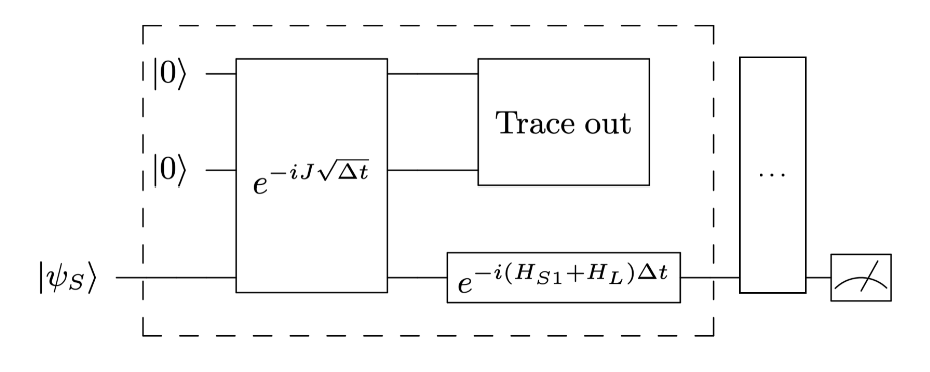

Here, J is defined as:
$$\begin{pmatrix} 0 & L_1^{\dagger} & ... & L_m^{\dagger} \\ L_1 & 0 & ... & 0 \\ \vdots & \vdots &  & \vdots \\ L_m & 0 & ... & 0 \end{pmatrix}$$

where the $L$'s are the Lindblad operators defined previously.

The $|0\rangle$ qubits are auxiliary qubits that help simulate the non-unitary evolution of the Lindblad equation. Adding these auxiliary qubits makes the whole system evolve unitarily. They are traced out after every time step.

### Helper Functions

In [13]:
def int_to_bits(idx: int, nbits: int) -> list[int]:
    """
    Extracts an integer's binary digits as a list of 0/1 values.
    """
    if idx < 0 or idx >= (1 << nbits):
        raise ValueError(f"idx = {idx} out of range for nbits = {nbits}")
    return [(idx >> q) & 1 for q in range(nbits)] # q = 0 is qubit 0

def int_to_bitstring(idx: int, nbits: int) -> str:
    """
    Converts an integer to binary as a string.
    """
    bits = int_to_bits(idx, nbits)
    return "".join(str(bits[q]) for q in reversed(range(nbits)))

In [14]:
# Checking int_to_bits and int_to_bitstring
binary_list = int_to_bits(3, 4)
print(binary_list)

print(int_to_bitstring(3, 4))

[1, 1, 0, 0]
0011


In [15]:
def ketbra_1q(ket: int, bra: int) -> SparsePauliOp:
    """
    |0><0| = 0.5(I + Z)
    |1><1| = 0.5(I - Z)
    |0><1| = 0.5(X + iY)
    |1><0| = 0.5(X - iY)
    """
    if ket == 0 and bra == 0:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])
    if ket == 1 and bra == 1:
        return SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])
    if ket == 0 and bra == 1:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", 0.5j)])
    if ket == 1 and bra == 0:
        return SparsePauliOp.from_list([("X", 0.5), ("Y", -0.5j)])
    raise ValueError("ket and bra must be 0 or 1")

def ketbra_from_bits(ket_bits: list[int], bra_bits: list[int]) -> SparsePauliOp:
    """
    Returns a SparsePauliOp for |ket><bra| on n qubits.
    ket_bits[q] corresponds to qubit q

    |ket><bra| = ⊗_{q=0}^{n-1} (|k_q><b_q|)
    """
    if len(ket_bits) != len(bra_bits):
        raise ValueError("ket_bits and bra_bits must have same length")
    n = len(ket_bits)
    if n == 0:
        raise ValueError("Need at least 1 qubit")

    op = ketbra_1q(ket_bits[n-1], bra_bits[n-1])
    for q in reversed(range(n-1)): # q = n-2 ... 0
        op = op.tensor(ketbra_1q(ket_bits[q], bra_bits[q]))
    return op.simplify()

def ketbra_from_ints(ket: int, bra: int, nbits: int) -> SparsePauliOp:
    """
    Straight from an integer to a tensor product.
    """
    return ketbra_from_bits(int_to_bits(ket, nbits), int_to_bits(bra, nbits))

In [16]:
# Checking functions
ket_bits = [1, 0] # qubit 0 is 1, qubit 1 is 0
bra_bits = [0, 1]

op = ketbra_from_bits(ket_bits = ket_bits, bra_bits = bra_bits)
M = op.to_matrix()
print(M)

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


### Building J operator

In [17]:
def build_J_operator(L_ops: list[SparsePauliOp], n_sys: int) -> SparsePauliOp:
    """
    J = sum_{j=1}^m ( |j><0| ⊗ L_j + |0><j| ⊗ L_j^† )
    """
    m = len(L_ops)
    n_aux = math.ceil(math.log2(m+1))
    if (1 << n_aux) < (m + 1):
        raise ValueError("n_aux sizing failed")

    total_qubits = n_aux + n_sys
    J = SparsePauliOp.from_list([("I" * total_qubits, 0.0)])

    for j, Lj in enumerate(L_ops, start=1):
        if j > m:
            break

        ket_j_bra_0 = ketbra_from_ints(j, 0, n_aux) # |j><0|
        ket_0_bra_j = ketbra_from_ints(0, j, n_aux) # |0><j|

        Lj_dag = Lj.adjoint()

        J += ket_j_bra_0.tensor(Lj)
        J += ket_0_bra_j.tensor(Lj_dag)

    return J.simplify()

### Checking J Operator Construction
Block (j, 0) in the aux basis should equal $L_j$, and block (0, j) should equal $L^{\dagger}_j$ with all other blocks zero.

The block structure should match:
$$J[j,0] = L_j$$
$$J[0,j] = L^{\dagger}_j$$

In [18]:
def check_J_blocks(J: SparsePauliOp, L_ops: list[SparsePauliOp], n_sys: int):
    m = len(L_ops)
    n_aux = J.num_qubits - n_sys
    d_aux = 2**n_aux
    d_sys = 2**n_sys

    Jm = J.to_matrix()
    Lmats = [L.to_matrix() for L in L_ops]

    def block(a, b):
        # aux block (a, b)
        r0, r1 = a*d_sys, (a+1)*d_sys
        c0, c1 = b*d_sys, (b+1)*d_sys
        return Jm[r0:r1, c0:c1]

    # Checking |j><0| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(j, 0) - Lmats[j-1])
        print(f"||J[{j},0] - L_{j}|| =", err)

    # Checking |0><j| blocks
    for j in range(1, m+1):
        err = np.linalg.norm(block(0, j) - Lmats[j-1].conj().T)
        print(f"||J[0,{j}] - L_{j}^†|| =", err)

In [19]:
L = 4
a_lat = 1.0
m_mass = 0.5
e_coup = 0.71
T = 5.0
    
H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
    
J = build_J_operator(L_ops = L_ops, n_sys = H.num_qubits)

check_J_blocks(J, L_ops, n_sys = H.num_qubits)

||J[1,0] - L_1|| = 9.813077866773595e-18
||J[2,0] - L_2|| = 1.3877787807814457e-17
||J[3,0] - L_3|| = 1.3877787807814457e-17
||J[4,0] - L_4|| = 9.813077866773595e-18
||J[0,1] - L_1^†|| = 9.813077866773595e-18
||J[0,2] - L_2^†|| = 1.3877787807814457e-17
||J[0,3] - L_3^†|| = 1.3877787807814457e-17
||J[0,4] - L_4^†|| = 9.813077866773595e-18


The Jong et al. (2021) paper assumes
$$\sum_j L_j \rho L_j^{\dagger} - \frac{1}{2}\{L_j^{\dagger}L_j, \rho\}$$
while mine is
$$a^2 \sum_{x_1, x_2} D(x_1 - x_2) \times (L(x_2)\rho_SL^{\dagger}(x_1) - \frac{1}{2} \{L^{\dagger}(x_1)L(x_2), \rho_S\}).$$

For non-diagonal environmental correlations (not delta functions), I need to diagonalize D before constructing the J operator. And then construct effective Lindblad operators.

$$D_{n_1, n_2} = \sum_{\alpha}\lambda_{\alpha} v_{n_1\alpha}v^{*}_{n_2\alpha}$$

$$\tilde{L}_{\alpha} = a \sqrt{\lambda_{\alpha}} \sum_n v^{*}_{n\alpha} L(n)$$

In [20]:
# Diagonalizing the environment correlation matrix
def diagonalized_lindblad_ops(
    raw_L_ops: list[SparsePauliOp],
    D: np.ndarray,
    a_lat: float,
    tol: float = 1e-12,
) -> list[SparsePauliOp]:
    """
    Convert correlated dissipator

        a^2 sum_{n1,n2} D[n1,n2]
        ( L[n2] rho L[n1]^dag - 1/2 {L[n1]^dag L[n2], rho} )

    into diagonal Lindblad form

        sum_alpha ( L_eff[alpha] rho L_eff[alpha]^dag
        - 1/2 {L_eff[alpha]^dag L_eff[alpha], rho} ).
    """
    D = np.asarray(D, dtype=complex)

    if D.shape != (len(raw_L_ops), len(raw_L_ops)):
        raise ValueError("D must have shape (len(raw_L_ops), len(raw_L_ops))")

    # D should be Hermitian positive semidefinite
    if not np.allclose(D, D.conj().T, atol=1e-10):
        raise ValueError("D must be Hermitian for Lindblad diagonalization")

    evals, evecs = np.linalg.eigh(D)

    eff_ops = []

    for alpha, lam in enumerate(evals):
        if lam < -tol:
            raise ValueError(f"D has negative eigenvalue {lam}; not completely positive")

        if lam <= tol:
            continue

        coeff = a_lat * np.sqrt(lam)

        # eigenvector column alpha: evecs[n, alpha]
        Lop_eff = None

        for n, Lop_n in enumerate(raw_L_ops):
            c = coeff * np.conj(evecs[n, alpha])

            if abs(c) <= tol:
                continue

            term = c * Lop_n

            if Lop_eff is None:
                Lop_eff = term
            else:
                Lop_eff = Lop_eff + term

        if Lop_eff is not None:
            eff_ops.append(Lop_eff.simplify())

    return eff_ops

#raw_L_ops = [L_n(n, H, L, a, T) for n in range(L)]
#D = D_matrix(L, a, kind="gaussian", D0=D0, sigma=sigma)
#
#effective_L_ops = diagonalized_lindblad_ops(raw_L_ops, D, a)
#
#J = build_J_operator(effective_L_ops, n_sys=L)

## Creating the Quantum Circuit
The dissipator is a sum of independent jump channels, and the circuit only reproduces the Lindblad equation to first order in $\Delta t$ anyway, so we Trotter-split it
$$e^{\mathcal{L}\Delta t}\approx \prod_{k} e^{\mathcal{L}_k \Delta t}$$
and dilate **one jump at a time** with the minimal single-ancilla block
$$J_k=\begin{pmatrix} 0 & L_k^\dagger \\ L_k & 0\end{pmatrix},$$
resetting and reusing the same ancilla qubit between each $k$. This is the standard Stinespring/collision-model dilation. The ancilla is what makes the non-unitary Lindblad evolution unitary on the enlarged space; resetting it after each jump is the partial trace.

**Why not dilate all $m$ jumps at once.** The obvious alternative packs every Lindblad operator into one big block operator
$$J = \begin{pmatrix} 0 & L_1^{\dagger} & ... & L_m^{\dagger} \\ L_1 & 0 & ... & 0 \\ \vdots & \vdots &  & \vdots \\ L_m & 0 & ... & 0 \end{pmatrix}$$
whose first row/column holds all $m$ Lindblad operators. That costs on two fronts:
1. **Width**: the ancilla has to index $m+1$ states, so it becomes a $\lceil \log_2(m+1)\rceil$-qubit register.
2. **Depth**: the transpiler sees $\exp(-i J \sqrt{\Delta t})$ as one big unitary over that register and synthesizes it as a black box. It doesn't exploit that each $L_j$ is a short Pauli string.

Splitting jump-by-jump drops the ancilla width from $\lceil\log_2(m+1)\rceil$ to $1$, and each $\exp(-i J_k \sqrt{\Delta t})$ becomes an ancilla-controlled rotation built directly from $L_k$'s Pauli terms (short CNOT ladders) rather than a slice of a dense unitary. This doesn't cut the *number* of coupling operations (~$m$ per step), but it cuts the per-operator cost sharply and sheds the ancilla register. Serializing the jumps adds an $O(\Delta t^2)$ splitting error — the same order as the dilation error already present — so it costs nothing in accuracy order.

In [21]:
def build_single_ancilla_circuit(
    H_op: SparsePauliOp,
    eff_L_ops: list[SparsePauliOp],
    n_sys: int,
    dt: float,
    n_steps: int,
    init_state=None,
    measure: bool = False,
    reps: int = 1,
) -> QuantumCircuit:
    """
    Build the dilation/Trotter circuit that reproduces the Lindblad equation in the
    limit dt -> 0, using a SINGLE reused ancilla qubit.

    The dissipator is split into independent single-jump channels

        exp(L dt) ~= prod_k exp(L_k dt),

    and each jump L_k is dilated with its own minimal 2x2 block

        J_k = |1><0| (x) L_k + |0><1| (x) L_k^dag      (one ancilla qubit),

    which is exactly build_J_operator([L_k], n_sys) with m = 1 -> n_aux = 1. The
    ancilla is reset (traced out) after each jump, so the same physical qubit is
    reused for every jump and every step -- no ceil(log2(m+1))-qubit aux register.

    Valid only for a memoryless (delta-in-time / Markovian) environment: reusing one
    ancilla assumes the bath keeps no memory between resets. Serializing the jumps
    adds an O(dt^2) Trotter-splitting error -- the same order as the dilation error
    already present -- so it costs nothing in accuracy order.

    One time step, with the single ancilla initialized in |0>:
        for each effective jump L_k:
            U_Jk = exp(-i J_k sqrt(dt))   on (sys + ancilla)
            reset the ancilla to |0>      (trace out -> ready for the next jump)
        U_H = exp(-i H dt)                on the system qubits

    Qubit-ordering convention: the SYSTEM register is added first, so the system
    occupies circuit qubits 0..n_sys-1 and the single ancilla is the high qubit
    n_sys. build_J_operator does ketbra_aux.tensor(L_sys), which puts the ancilla in
    the high position of each J_k, hence jk_qubits = sys_qubits + [ancilla]. Drawing
    the circuit therefore shows the system on top and the ancilla on the bottom.
    rho_vs_cycles below relies on this "system low, ancilla high" layout when it
    traces the ancilla out.

    Parameters
    ----------
    H_op       : system Hamiltonian (acts on n_sys qubits).
    eff_L_ops  : effective (D-diagonalized) jump operators, each dilated separately
                 -- see diagonalized_lindblad_ops.
    n_sys      : number of system qubits.
    dt         : Trotter time step (note U_Jk uses sqrt(dt), U_H uses dt).
    n_steps    : number of Trotter steps.
    init_state : optional initial state on the SYSTEM qubits. Accepts anything
                 qiskit's initialize() takes -- a statevector array of length
                 2**n_sys, an int, or a bitstring label (e.g. "0101"). The ancilla
                 always starts in |0>.
    measure    : if True, add a classical register and measure the system qubits.
    reps       : Trotter repetitions used when each PauliEvolutionGate is
                 synthesized into native gates (passed to LieTrotter).

    Returns
    -------
    QuantumCircuit with registers s (system) and a (1 ancilla), and optionally c.
    """
    if H_op.num_qubits != n_sys:
        raise ValueError(f"H_op acts on {H_op.num_qubits} qubits but n_sys = {n_sys}.")

    synth = LieTrotter(reps=reps)
    # One minimal single-ancilla dilation gate per effective jump operator.
    U_Jk = [
        PauliEvolutionGate(build_J_operator([Lk], n_sys=n_sys),
                           time=np.sqrt(dt), synthesis=synth)
        for Lk in eff_L_ops
    ]
    U_H = PauliEvolutionGate(H_op, time=dt, synthesis=synth)

    aux = QuantumRegister(1, "a")
    sys = QuantumRegister(n_sys, "s")
    qc = QuantumCircuit(sys, aux)          # system register first -> system on top when drawn
    sys_qubits = list(sys)
    aux_q = aux[0]
    jk_qubits = sys_qubits + [aux_q]       # system low, ancilla high (matches build_J_operator)

    if init_state is not None:
        qc.initialize(init_state, sys_qubits)
        qc.barrier()

    for _ in range(n_steps):
        for U in U_Jk:
            qc.append(U, jk_qubits)        # exp(-i J_k sqrt(dt)) on sys + ancilla
            qc.reset(aux_q)                # trace out this jump; ancilla back to |0>
        qc.append(U_H, sys_qubits)         # exp(-i H dt) on sys
        qc.barrier()

    if measure:
        creg = ClassicalRegister(n_sys, "c")
        qc.add_register(creg)
        qc.measure(sys_qubits, creg)

    return qc

### Visualizing one Trotter step

Draw ONE Trotter step (logical, pre-transpile) so the structure stays legible — the
transpiled circuit is thousands of gates and unreadable. Each dilation shows up as a
single labeled block: $m$ narrow $\exp(-iJ_k\sqrt{dt})$ blocks in series, each
touching only the one ancilla, with a `reset` on that ancilla between them, then
$\exp(-iH\,dt)$ on the system.

system qubits = 4, ancilla = 1, total = 5  --  4 exp(-iJ_k.sqrt(dt)) blocks, reset between each


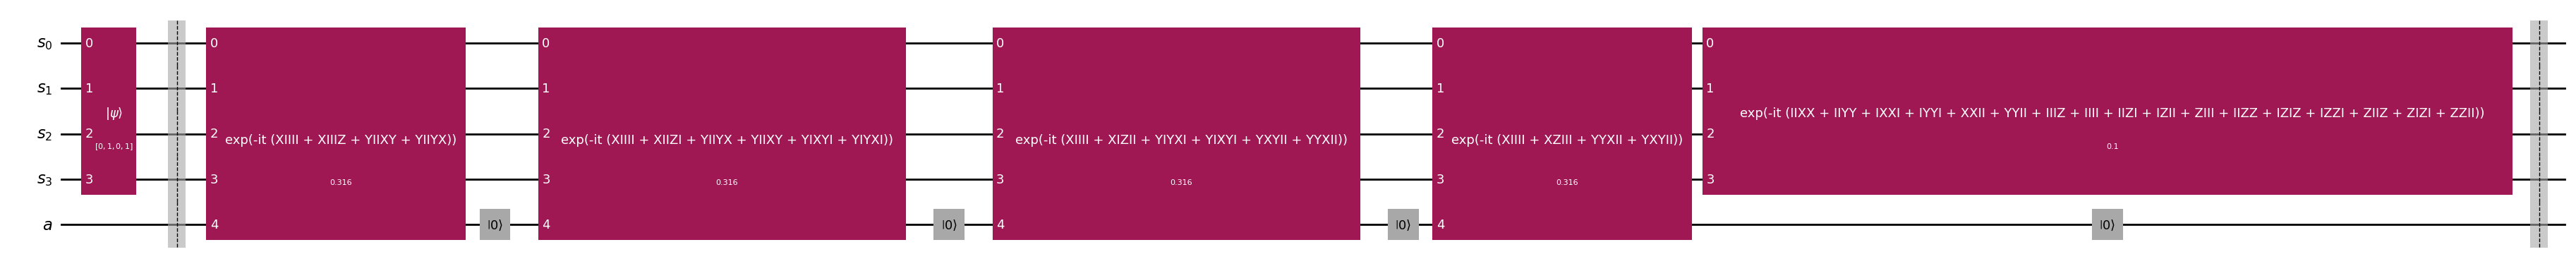

In [22]:
# --- Demo: build and draw one Trotter step of the single-ancilla circuit ---
L = 4
a_lat = 1.0
m_mass = 0.5
e_coup = 0.71
T = 5.0
dt = 0.1

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits

# Jump operators -> effective jumps. For non-delta correlations
# diagonalized_lindblad_ops handles the off-diagonal D[n1,n2] terms.
raw_L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
eff_L_ops = diagonalized_lindblad_ops(
    raw_L_ops, D_matrix(L, a_lat, kind="delta", D0=1.0), a_lat)

# Initialize the system qubits. Examples (pick one):
#   init_state = "0101"                 # computational basis (bitstring)
#   init_state = 5                      # same, as an integer
#   init_state = some_numpy_statevector # length 2**n_sys, normalized
init_state = "0101"

qc = build_single_ancilla_circuit(
    H_op=H, eff_L_ops=eff_L_ops, n_sys=n_sys,
    dt=dt, n_steps=1, init_state=init_state,
)

print(f"system qubits = {n_sys}, ancilla = 1, total = {qc.num_qubits}  --  "
      f"{len(eff_L_ops)} exp(-iJ_k.sqrt(dt)) blocks, reset between each")
qc.draw("mpl", fold=-1, idle_wires=False)

# Tip: to *see* the gate-count blow-up, look at the transpiled version instead --
# it is huge, so print op counts rather than drawing it:
#   pm.run(qc.decompose(reps=6)).count_ops()
# Bump n_steps (e.g. 2) to see how a step repeats.

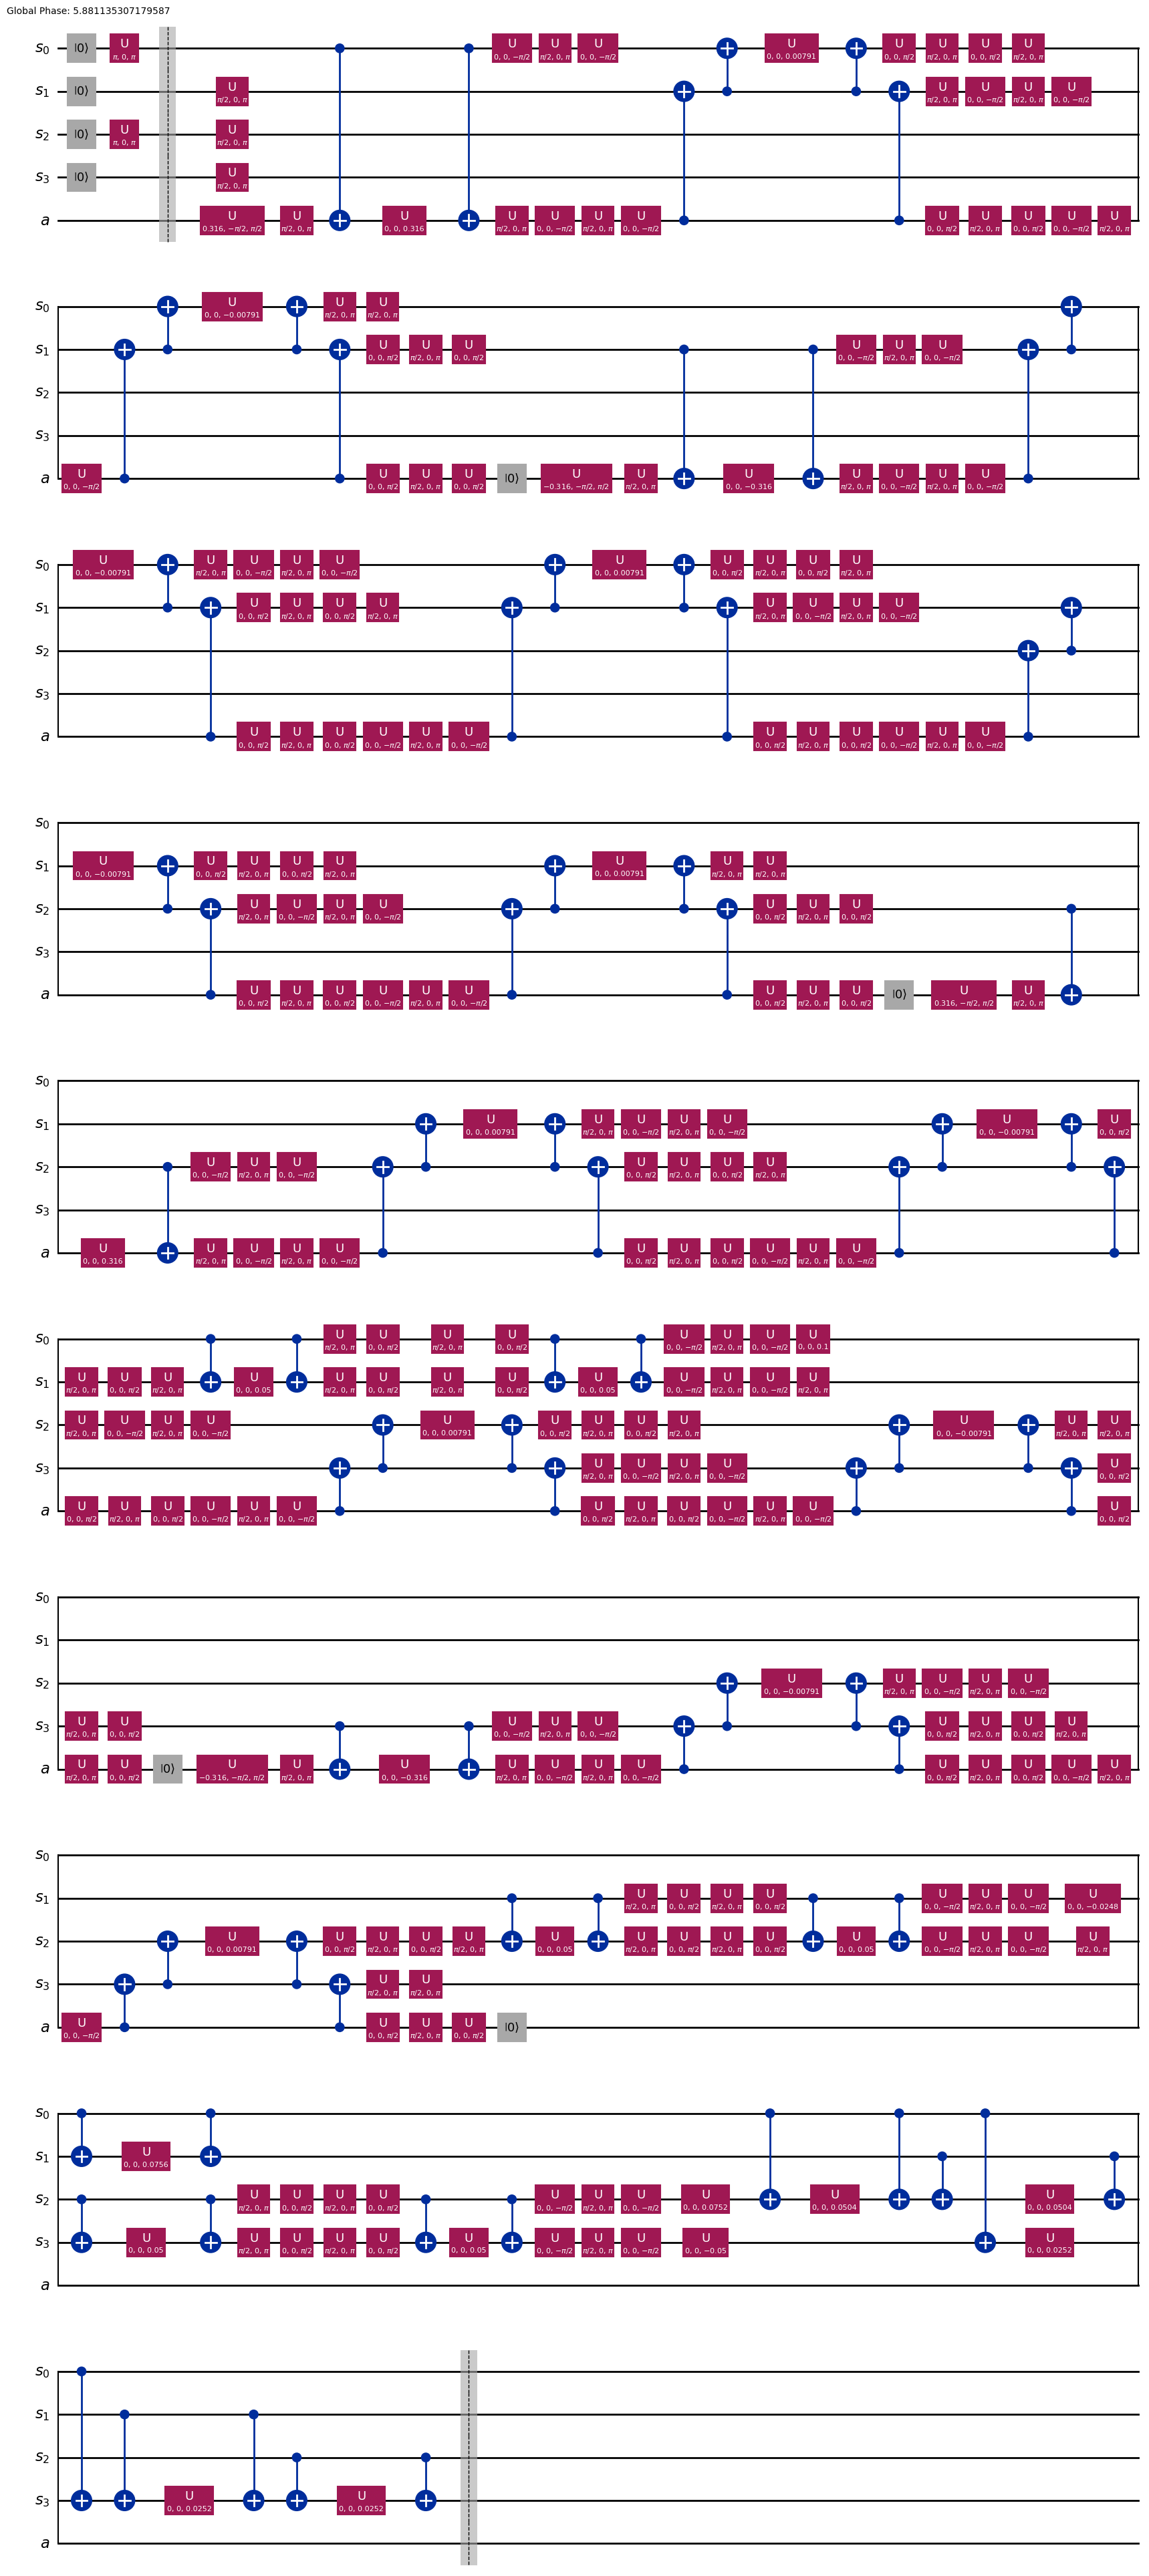

In [23]:
pm.run(qc.decompose(reps=6)).draw("mpl", idle_wires=False)

## Thermal State Preparation
The steady state is the Gibbs state,

$$
\rho_\mathrm{ss} = \frac{e^{-\beta H}}{Z}.
$$

The auxiliary qubits and resets in each Trotter cycle act as a synthetic bath that pumps entropy in and out until the system settles into thermal equilibrium at the temperature set by the Lindblad operators.

We'll use "enough" Trotter cycles for the initial state to relax to a steady state. Recall that the fixed point is unique and independent of the initial state. The number of "enough" cycles is set by the Liouvillian spectral gap. The nonzero eigenvalue with the largest real part is the slowest-decaying mode. The relaxation time is roughly

$$
\tau \approx \frac{1}{|\mathrm{Re}(\lambda_\mathrm{gap})|}.
$$

So, the total evolved time

$$
t = n_\mathrm{steps} \cdot dt
$$

needs to be several multiples of $\tau$. Therefore,

$$
n_\mathrm{steps} \approx \frac{(\text{a few})\,\tau}{dt}.
$$


$dt$ must be small so each cycle's first-order Trotter approximation is accurate. And, $n_\text{steps}\cdot dt$ must be large so I actually reach the steady state.

**How I'll know I've reached the thermal state"**
 - Track the fidelity $F(n) = \mathrm{Tr}\sqrt{\rho^{1/2}(n)\,\rho_\mathrm{th}\,\rho^{1/2}(n)}$ between the circuit state and the theoretical thermal state vs cycle number. When it flattens near 1, I've reached the steady state.
 - Run from a few different initial states. If they converge to the same observables, I'm at the unique fixed point.
 - Compare to the exact Gibbs state (since my system is small) -- restricted to the charge sector the dynamics can actually reach.
 - The exact steady state is the zero-eigenvalue eigenvector of the Liouvillian matrix. Reshape the steady state into a density matrix and compare to $e^{-\beta H}/Z$.

### Tracking Fidelity to the Thermal State vs Cycle Number
The observable is the **Uhlmann fidelity** between the state the circuit actually prepares and the theoretical thermal state,

$$
F(n) \;=\; \mathrm{Tr}\sqrt{\rho^{1/2}(n)\,\rho_\mathrm{th}\,\rho^{1/2}(n)},
\qquad
\rho_\mathrm{th} = \frac{e^{-H/T}}{Z},
$$

where $\rho(n)$ is the reduced system state after $n$ Lindblad/Trotter cycles (auxiliaries traced out). $F \in [0, 1]$, and $F = 1$ **iff** $\rho(n) = \rho_\mathrm{th}$. This replaces $\langle H \rangle$ as the convergence diagnostic: the energy is a single number that two very different states can share, whereas $F = 1$ pins down the *entire* density matrix. (Convention: this is the square root of qiskit's `state_fidelity`, which returns $F^2$.)

**Why there is no `Estimator` here.** $F$ is *not* a linear functional of $\rho$, so it is not a Qiskit observable and no `Estimator` can return it. Instead we read the density matrix out directly with `save_density_matrix` on an `AerSimulator(method="density_matrix")` — exact, no shots, no sampling error. A density-matrix simulation is required in any case: each cycle resets the auxiliary qubits, tracing them out, so the reduced system state is *mixed* and a statevector run would only sample one random reset trajectory.

**What to compare against — the charge sector matters.** The Lindblad operators $L(n) = O(n) - \frac{1}{4T}[H, O(n)]$ are built from $O(n)\propto\sigma_z(n)$ and commute with the total charge $\sum_n \sigma_z(n)$, which $H$ also conserves. So the dissipative dynamics **never leaves the charge sector of the initial state**: from $|0101\rangle$ ($S_z=0$) it can only reach other $S_z=0$ states. The reachable target is therefore the Gibbs state *restricted to that sector*, embedded back into the full Hilbert space — **not** the full-Hilbert-space Gibbs state. We plot $F$ against both: it should climb toward 1 for the sector target, while the full-Gibbs curve saturates far below 1, at the overlap between the sector Gibbs state and the full one. To actually target the full Gibbs state, average over initial states from every charge sector.

In [24]:
# ============================================================
#  Observable: fidelity to the theoretical thermal state
#      F(rho, sigma) = Tr sqrt( rho^{1/2} sigma rho^{1/2} )
# ============================================================
# F is NONLINEAR in rho, so it is not a Qiskit observable and no Estimator can
# return it -- we read rho out exactly with save_density_matrix instead (next cell).
from qiskit.quantum_info import DensityMatrix, partial_trace

# Exact (shot-free) density-matrix simulator. Needed whatever the observable: each
# cycle resets/traces out the auxiliaries, so the reduced system state is MIXED.
sim_dm = AerSimulator(method="density_matrix")


def _basis_bits(init_state, n):
    """Computational-basis state -> bit list with bits[q] = qubit q.

    Matches qiskit's initialize(label) convention: the RIGHTMOST character of a
    bitstring is qubit 0. Accepts a bitstring (e.g. "0101") or an int.
    """
    if isinstance(init_state, str):
        return [int(b) for b in reversed(init_state)]
    if isinstance(init_state, (int, np.integer)):
        return [(int(init_state) >> i) & 1 for i in range(n)]
    raise TypeError("init_state must be a bitstring or int (basis state).")


def _sqrtm_psd(A):
    """Matrix square root of a Hermitian positive-semidefinite matrix."""
    w, v = np.linalg.eigh(np.asarray(A, dtype=complex))
    return (v * np.sqrt(np.clip(w.real, 0.0, None))) @ v.conj().T   # clip kills -1e-17


def uhlmann_fidelity(rho, sigma):
    """F(rho, sigma) = Tr sqrt( rho^{1/2} sigma rho^{1/2} ),  in [0, 1]; 1 iff equal.

    Evaluated as the nuclear norm (sum of singular values) || rho^{1/2} sigma^{1/2} ||_1,
    which is the same quantity but stays stable for the RANK-DEFICIENT states here:
    the sector-restricted Gibbs state is singular on the full Hilbert space, so a
    naive sqrtm of the triple product is badly conditioned.

    Convention: this is the SQUARE ROOT of qiskit's state_fidelity(), which returns F**2.
    """
    M = _sqrtm_psd(rho) @ _sqrtm_psd(sigma)
    return float(np.clip(np.linalg.svd(M, compute_uv=False).sum(), 0.0, 1.0))


def gibbs_dm(H_op, T, sector_of=None):
    """Theoretical thermal state rho_th = e^{-H/T} / Z, as a dense matrix.

    sector_of : None          -> full Hilbert space.
                bitstring/int -> restrict to the total-charge (Sz) sector holding
                                 that basis state, then embed back into the full
                                 space. The Lindblad jumps L(n) ~ Z(n) conserve Sz,
                                 so the circuit can only ever reach this sector: it
                                 is the physically reachable target.

    Returns (rho_th, Q0), with Q0 the sector's Sz (None for the full space).
    """
    n = H_op.num_qubits
    Hd = H_op.to_matrix()

    if sector_of is None:
        ev, U = np.linalg.eigh(Hd)
        w = np.exp(-(ev - ev.min()) / T)              # shift for numerical stability
        return (U * (w / w.sum())) @ U.conj().T, None

    bits = _basis_bits(sector_of, n)
    Q0 = bits.count(0) - bits.count(1)                # Sz eigenvalue of |init>
    idx = [i for i in range(2 ** n) if n - 2 * bin(i).count("1") == Q0]
    ev, U = np.linalg.eigh(Hd[np.ix_(idx, idx)])
    w = np.exp(-(ev - ev.min()) / T)
    rho = np.zeros((2 ** n, 2 ** n), dtype=complex)
    rho[np.ix_(idx, idx)] = (U * (w / w.sum())) @ U.conj().T
    return rho, Q0

In [25]:
def rho_vs_cycles(one_step, n_sys, cycle_list, init_state):
    """Reduced system density matrix rho(n) after each cycle count in cycle_list.

    `one_step` is a BARE one-step circuit (no initial state, no measurement) whose
    system register was added first, so the system is qubits 0..n_sys-1 and any
    auxiliaries follow at n_sys.. -- build_single_ancilla_circuit satisfies this
    (system low, ancilla high).

    The step is decomposed ONCE and then repeated, with a save_density_matrix
    instruction dropped at every requested cycle count, so the whole curve comes out
    of a SINGLE Aer run instead of one deep circuit per point. The auxiliaries are
    traced out at each save. Exact -- no measurements, no shots.

    Returns a list of dense arrays aligned with cycle_list (n = 0 is the initial
    state, before any cycle).
    """
    step = one_step.decompose(reps=6)   # resolve PauliEvolutionGate once, not per cycle
    n_total = one_step.num_qubits
    aux = list(range(n_sys, n_total))   # auxiliaries are the high qubits

    qc = QuantumCircuit(n_total)
    for q, bit in enumerate(_basis_bits(init_state, n_sys)):
        if bit:
            qc.x(q)                     # basis-state prep with X gates

    cps = sorted({int(c) for c in cycle_list if c >= 0})
    if not cps:
        raise ValueError("cycle_list must hold at least one nonnegative cycle count.")
    if 0 in cps:
        qc.save_density_matrix(label="c0")
    for n in range(1, max(cps) + 1):
        qc.compose(step, inplace=True)
        if n in cps:
            qc.save_density_matrix(label=f"c{n}")

    data = sim_dm.run(qc).result().data(0)
    rhos = {}
    for n in cps:
        dm = DensityMatrix(data[f"c{n}"])
        rhos[n] = np.asarray((partial_trace(dm, aux) if aux else dm).data)
    return [rhos[int(c)] for c in cycle_list]


def fidelity_vs_cycles(one_step, n_sys, cycle_list, init_state, rho_target):
    """F(rho(n), rho_target) = Tr sqrt(rho^{1/2} rho_target rho^{1/2}) vs cycle count.

    Returns a numpy array aligned with cycle_list. rho_target is normally
    gibbs_dm(H, T, sector_of=init_state)[0] -- the sector-restricted Gibbs state,
    which is the only thermal state the charge-conserving dynamics can reach.
    """
    return np.array([uhlmann_fidelity(rho, rho_target)
                     for rho in rho_vs_cycles(one_step, n_sys, cycle_list, init_state)])

final F vs Gibbs, Sz=2 sector (cycle 200) : 0.99962   <- circuit target
final F vs Gibbs, full Hilbert space              : 0.48695
ceiling F(sector Gibbs, full Gibbs)               : 0.48713


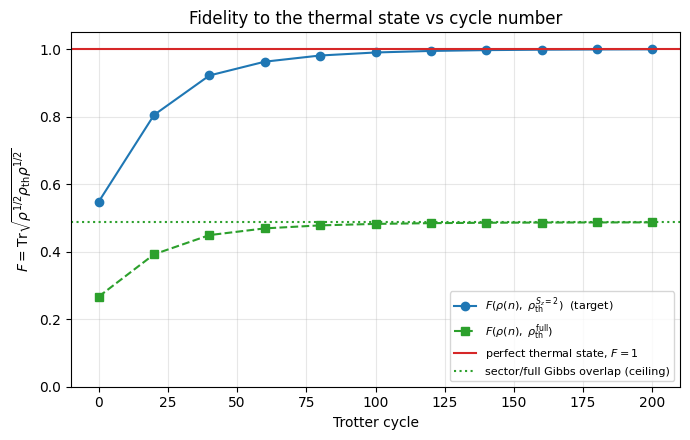

In [26]:
# ============================================================
#  CONTROL PANEL -- set everything for this run in one place
# ============================================================
# Physics
L      = 4             # fermion sites = system qubits
a_lat  = 1.0           # lattice spacing
m_mass = 0.5           # fermion mass
e_coup = 0.71          # gauge coupling
T      = 5.0           # bath temperature, sets both L(n) and the target Gibbs state

# Environment correlator D(x)
D_kind  = "delta"      # "delta" | "gaussian" | "const"
D0      = 1.0          # overall coupling strength
D_sigma = 1.0          # correlation length (only used when D_kind == "gaussian")

# Trotter / evolution
dt          = 0.1      # Trotter time step
cycle_start = 0        # first cycle count to sample
cycle_stop  = 200      # last cycle count (inclusive)
cycle_step  = 20       # spacing between sampled cycle counts

# Initial system state (bitstring; rightmost char is qubit 0)
init_state = "0001"
# ============================================================
# NOTE: cost grows with cycle_stop -- the circuit is evolved once out to the largest
# cycle count, saving rho along the way. Raise cycle_stop to confirm the plateau.

cycle_list = list(range(cycle_start, cycle_stop + 1, cycle_step))

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits

# Rebuild the dissipator for the chosen correlator D. For non-delta correlations
# diagonalized_lindblad_ops handles the off-diagonal D[n1,n2] terms.
D = D_matrix(L, a_lat, kind=D_kind, D0=D0,
             sigma=(D_sigma if D_kind == "gaussian" else None))
raw_L_ops = [L_n(n=n, H=H, L=L, a=a_lat, T=T) for n in range(L)]
eff_L_ops = diagonalized_lindblad_ops(raw_L_ops, D, a_lat)

# --- Theoretical thermal states to compare against ---
rho_sector, Q0 = gibbs_dm(H, T, sector_of=init_state)   # reachable target
rho_full, _    = gibbs_dm(H, T)                         # full Hilbert space

# --- Track F(rho(n), rho_th) vs cycle number ---
one_step = build_single_ancilla_circuit(H_op=H, eff_L_ops=eff_L_ops, n_sys=n_sys,
                                        dt=dt, n_steps=1)
rhos = rho_vs_cycles(one_step, n_sys, cycle_list, init_state)
F_sector = np.array([uhlmann_fidelity(r, rho_sector) for r in rhos])
F_full   = np.array([uhlmann_fidelity(r, rho_full)   for r in rhos])

# Ceiling on the full-Gibbs curve: even a PERFECT sector thermal state only overlaps
# the full Gibbs state this much, because it lives entirely in one charge sector.
F_ceiling = uhlmann_fidelity(rho_sector, rho_full)

print(f"final F vs Gibbs, Sz={Q0} sector (cycle {cycle_list[-1]}) : {F_sector[-1]:.5f}   <- circuit target")
print(f"final F vs Gibbs, full Hilbert space              : {F_full[-1]:.5f}")
print(f"ceiling F(sector Gibbs, full Gibbs)               : {F_ceiling:.5f}")

# --- Plot ---
plt.figure(figsize=(7, 4.5))
plt.plot(cycle_list, F_sector, "o-",
         label=fr"$F(\rho(n),\ \rho_\mathrm{{th}}^{{S_z={Q0}}})$  (target)")
plt.plot(cycle_list, F_full, "s--", color="tab:green",
         label=r"$F(\rho(n),\ \rho_\mathrm{th}^\mathrm{full})$")
plt.axhline(1.0, ls="-", color="tab:red", label="perfect thermal state, $F=1$")
plt.axhline(F_ceiling, ls=":", color="tab:green",
            label="sector/full Gibbs overlap (ceiling)")
plt.xlabel("Trotter cycle")
plt.ylabel(r"$F = \mathrm{Tr}\sqrt{\rho^{1/2}\rho_\mathrm{th}\rho^{1/2}}$")
plt.title("Fidelity to the thermal state vs cycle number")
plt.ylim(0, 1.05)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## $dt$ and $n_\text{cycles}$ for convergence within $10\%$ of the theoretical state

In [27]:
# ============================================================
# dt vs n_cycles analysis -- CONVERGENCE within `tol` of the theoretical state
# ============================================================
# Robust for ANY computational-basis initial state: set `init_state` in the control
# panel below and everything (its total-charge sector, that sector's Gibbs state, and
# the feasible dt / n_cycles region) is derived from it.
#
# The observable is the Uhlmann fidelity to the target thermal state,
#     F(n) = Tr sqrt( rho(n)^{1/2} rho_th rho(n)^{1/2} ),
# with rho_th the Gibbs state of init_state's charge sector. Its theoretical value is
# EXACTLY 1, so "within 10% of the theoretical value" reads the same absolutely or
# relatively:  |F - 1| <= tol  <=>  F >= 1 - tol.  No state-dependent reference value
# is involved, unlike the relative error on <H> this replaces -- there the target E*
# varied by sector, and a small |E*| made a fixed absolute offset look like a huge
# relative one.
#
# rho(n) is read EXACTLY (density-matrix simulator + save_density_matrix, NO shots).


def sa_fidelity_curve_exact(H_op, eff_L_ops, n_sys, dt, cycle_points, init_state,
                            rho_target):
    """Exact F(rho(n), rho_target) at each n in cycle_points, single-ancilla circuit.

    Thin wrapper over fidelity_vs_cycles for one bare single-ancilla Trotter step.
    n = 0 is allowed and means the initial state, before any cycle. Returns (ns, Fs)
    as numpy arrays; init_state must be a computational-basis bitstring/int."""
    step = build_single_ancilla_circuit(H_op=H_op, eff_L_ops=eff_L_ops, n_sys=n_sys,
                                         dt=dt, n_steps=1)
    ns = np.array(sorted({int(c) for c in cycle_points if c >= 0}))
    return ns, fidelity_vs_cycles(step, n_sys, ns, init_state, rho_target)


def analyze_dt_ncycles(H_op, eff_L_ops, n_sys, init_state, T, dt_list,
                       t_max=60.0, tol=0.10, settle_tol=0.02, n_samples=120,
                       verbose=True):
    """For each dt, how many cycles until the prepared state is within `tol` of the
    theoretical thermal state, measured by fidelity.

    Each dt yields two cycle counts, answering DIFFERENT questions -- keeping them
    apart is the whole point of this function:

      * n_tol    = fewest cycles from which F >= 1 - tol for every later sample.
                   This is the headline: "within tol of the theoretical state".
      * n_settle = fewest cycles from which |F - plateau| <= settle_tol onwards, i.e.
                   the point past which more cycles buy nothing AT THIS dt. Strictly
                   the harder condition whenever the plateau sits well above the band,
                   which it does at every usable dt -- so do not read n_settle as the
                   answer to "within tol"; it is much more conservative.

    plus the two numbers that describe the dt error itself:

      * plateau  = steady F at this dt (the dt-limited fixed point of the circuit).
      * floor    = 1 - plateau, the systematic infidelity that dt leaves behind no
                   matter how long you run. It is therefore also the TIGHTEST tol this
                   dt can ever reach: ask for tol < floor and n_tol comes back None
                   ("never" -- decrease dt).

    F(n) rises MONOTONICALLY here: the Uhlmann fidelity is non-decreasing under a CPTP
    map that fixes the target, and the circuit's fixed point is very close to rho_th.
    So -- unlike the <H> curve this replaces, which could overshoot and dip through
    the band during a transient -- band entry is genuine and needs no separate
    "settling" safeguard. `worst dF` is printed as a running check on that claim; if
    it ever grows comparable to tol, the "and stays" logic here needs revisiting.

    Returns (sweep, rho_target, Q0) with
        sweep[dt] = (ns, Fs, plateau, n_tol, floor, n_settle).
    Raise t_max if a row warns that the tail has not flattened."""
    rho_target, Q0 = gibbs_dm(H_op, T, sector_of=init_state)
    dim = int(np.count_nonzero(np.linalg.eigvalsh(rho_target) > 1e-12))

    if verbose:
        print(f"init_state = {init_state!r}  ->  charge sector Sz = {Q0}, "
              f"dimension {dim}")
        if dim == 1:
            print("  (!) that sector holds a SINGLE state, so rho_th = |init><init|:")
            print("      F = 1 before any cycle runs and there is nothing to converge.")
        print(f"target = Gibbs state of that sector at T = {T}, whose F is exactly 1")
        print(f"within {tol:.0%} of the theoretical state  <=>  F >= {1 - tol:g}\n")
        print(f"{'dt':>6}{'plateau F':>12}{'floor':>10}{'n_tol':>7}{'t_tol':>8}"
              f"{'n_settle':>10}{'worst dF':>11}{'grid':>7}")

    out = {}
    for dt in dt_list:
        Nmax = max(2, int(round(t_max / dt)))
        pts = np.unique(np.concatenate([
            np.arange(0, min(Nmax, 40) + 1),
            np.linspace(0, Nmax, n_samples)]).astype(int))
        ns, Fs = sa_fidelity_curve_exact(H_op, eff_L_ops, n_sys, dt, pts,
                                         init_state, rho_target)
        plateau = float(Fs[-1])
        floor = 1.0 - plateau
        worst_dF = float(np.diff(Fs).min()) if len(Fs) > 1 else 0.0

        first = lambda mask: next((int(ns[k]) for k in range(len(ns))
                                   if mask[k:].all()), None)
        n_tol = first(Fs >= 1.0 - tol)
        n_settle = first(np.abs(Fs - plateau) <= settle_tol)

        # sampling gap just below n_tol, so the cycle count is not over-read
        def _grid(n):
            if n is None:
                return 0
            k = int(np.where(ns == n)[0][0])
            return int(ns[k] - ns[k - 1]) if k > 0 else 0

        out[dt] = (ns, Fs, plateau, n_tol, floor, n_settle)

        if verbose:
            # The tail check has to be calibrated to the FLOOR, not to settle_tol:
            # settle_tol (~1e-2) is orders of magnitude larger than the floor (~1e-4),
            # so a settle_tol-sized test passes trivially while the plateau -- and
            # hence the floor and its fitted dt exponent -- is still drifting.
            drift = abs(Fs[-1] - Fs[max(0, len(Fs) - 6)])
            tail_flat = drift <= max(0.05 * floor, 1e-12)
            nt = f"{n_tol}" if n_tol is not None else "never"
            tt = f"{n_tol * dt:.1f}" if n_tol is not None else "-"
            nset = f"{n_settle}" if n_settle is not None else "never"
            warn = "" if tail_flat else f"  (!) floor still drifting ({drift:.0e}), raise t_max"
            print(f"{dt:>6.3f}{plateau:>12.6f}{floor:>10.1e}{nt:>7}{tt:>8}"
                  f"{nset:>10}{worst_dF:>11.1e}{'+' + str(_grid(n_tol)):>7}{warn}")

    if verbose:
        dts = np.array(dt_list, dtype=float)
        fls = np.array([out[d][4] for d in dt_list], dtype=float)
        good = fls > 0
        if good.sum() >= 2:
            slope = float(np.polyfit(np.log(dts[good]), np.log(fls[good]), 1)[0])
            print(f"\n  systematic infidelity floor ~ dt^{slope:.2f}")
            print(f"  A state error linear in dt shows up QUADRATICALLY in the "
                  f"fidelity,")
            print(f"  because F is stationary at its maximum -- consistent with the "
                  f"<H>")
            print(f"  plateau offset, which was linear in dt.")
        ts = [out[d][3] * d for d in dt_list if out[d][3] is not None]
        if ts:
            print(f"  Physical time to reach the band is dt-independent: t_tol = "
                  f"{min(ts):.1f}-{max(ts):.1f}.")
            print(f"  So n_tol just scales like 1/dt -- halving dt doubles the cycles "
                  f"for the same physics.")
    return out, rho_target, Q0

### Set an initial state and read off dt / $n_\text{cycles}$

Set `init_state` (any computational-basis bitstring, e.g. `"0101"`, or an int) in the
control panel below and run.

**What "within 10%" means here.** The theoretical value of the fidelity is exactly
$F = 1$, so a 10% tolerance is the same statement read absolutely or relatively:
$|F - 1| \leq 0.1 \Longleftrightarrow F \geq 0.9$. That is `n_tol`, the headline
number, and it is the one that answers the section title.

**No overshoot to guard against.** The Uhlmann fidelity is non-decreasing under a CPTP
map that fixes the target, and the circuit's fixed point sits very close to
$\rho_\mathrm{th}$, so $F(n)$ climbs monotonically (the table prints `worst dF` as a
check — it stays at the $10^{-5}$ level, i.e. numerical). This is a real change from
the $\langle H\rangle$ version of this analysis: energy could start *above* its plateau,
plunge through the band and dip back out, so band entry there was not trustworthy and
had to be replaced by a settling test. Here band entry *is* convergence.

`n_settle` is still reported, but it now answers a different and stricter question —
*when does running longer stop helping at this `dt`?* — and it lands roughly $2\times$
later than `n_tol`. Do not read it as the 10% answer.

**What `dt` actually controls.** Only the plateau: the systematic infidelity `floor`
$= 1 - F_\text{plateau}$ that survives however long you run. It scales as $dt^2$ (the
table fits the exponent), which is exactly what a state error linear in $dt$ looks like
through a fidelity — $F$ is stationary at its maximum, so first-order state errors
enter $1-F$ at second order. This is consistent with the old $\langle H\rangle$ plateau
offset being *linear* in $dt$.

The practical consequence: at a 10% tolerance the floor is three to four orders of
magnitude below the band, so **`dt` is not the binding constraint at all** — every
`dt` in the list reaches the band, and `never` cannot occur. `dt` only starts to bind
at much tighter tolerances, which is what the final table sweeps. Meanwhile the
*physical* time to reach the band is `dt`-independent, so `n_tol` simply scales like
$1/dt$: a smaller `dt` buys a better floor and costs proportionally more cycles.

In [28]:
# ---- Control panel: set your initial state (and physics) here --------------
init_state = "0001"          # any computational-basis bitstring (e.g. "0101") or int
L      = 4
a_lat  = 1.0
m_mass = 0.5
e_coup = 0.71
T      = 5.0
D0     = 1.0                 # delta-correlator strength
dt_list = [0.40, 0.30, 0.20, 0.15, 0.10, 0.05]
t_max   = 60.0               # physical-time horizon; long enough for F to plateau
tol        = 0.10            # within tol of the theoretical state <=> F >= 1 - tol
settle_tol = 0.02            # "settled" = within this much of the plateau F (a stricter, secondary question)

# Build H and the effective (diagonalized) delta-correlator jump operators.
H_an     = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys_an = H_an.num_qubits
raw_L_an = [L_n(n=n, H=H_an, L=L, a=a_lat, T=T) for n in range(L)]
eff_L_an = diagonalized_lindblad_ops(
    raw_L_an, D_matrix(L, a_lat, kind="delta", D0=D0), a_lat)

sweep, rho_target, Q0 = analyze_dt_ncycles(
    H_an, eff_L_an, n_sys_an, init_state, T, dt_list,
    t_max=t_max, tol=tol, settle_tol=settle_tol)

# --- Headline: cheapest way to land within tol of the theoretical state ------
feasible = {dt: v[3] for dt, v in sweep.items() if v[3] is not None}
if feasible:
    dt_best = min(feasible, key=lambda d: feasible[d])
    print(f"\nWithin {tol:.0%} of the theoretical state in the fewest cycles: "
          f"dt = {dt_best:g}  ->  {feasible[dt_best]} cycles "
          f"(physical time t = {feasible[dt_best] * dt_best:.1f}).")
    print(f"  Its floor is {sweep[dt_best][4]:.1e}, far below the {tol:.0%} band, so "
          f"the band is reached\n  by RELAXATION, not limited by dt.")
else:
    print(f"\nNo dt in dt_list reaches F >= {1 - tol:g} -- add smaller dt values.")

# --- Where dt does bind: tighter targets -------------------------------------
# Re-read the SAME curves at tighter tolerances. A dt is usable only if its floor
# clears the target; among those, the largest dt needs the fewest cycles.
print(f"\nTightening the target (largest usable dt in dt_list, and its cost):")
print(f"{'target':>9}{'dt':>8}{'floor':>10}{'cycles':>9}{'time':>8}")
for eps in (0.10, 0.01, 1e-3, 1e-4, 1e-5):
    hit = None
    for dt in sorted(dt_list, reverse=True):          # largest dt = fewest cycles
        ns, Fs, plateau, _, floor, _ = sweep[dt]
        if floor > eps:
            continue                                   # this dt can never get there
        n = next((int(ns[k]) for k in range(len(ns))
                  if (Fs[k:] >= 1.0 - eps).all()), None)
        if n is not None:
            hit = (dt, floor, n, n * dt)
            break
    if hit:
        print(f"{eps:>8.3%}{hit[0]:>8g}{hit[1]:>10.1e}{hit[2]:>9}{hit[3]:>8.1f}")
    else:
        print(f"{eps:>8.3%}{'none':>8}{'':>10}{'':>9}{'':>8}   floor too high at every dt")

init_state = '0001'  ->  charge sector Sz = 2, dimension 4
target = Gibbs state of that sector at T = 5.0, whose F is exactly 1
within 10% of the theoretical state  <=>  F >= 0.9

    dt   plateau F     floor  n_tol   t_tol  n_settle   worst dF   grid
 0.400    0.999101   9.0e-04      9     3.6        18   -2.9e-05     +1
 0.300    0.999496   5.0e-04     12     3.6        25   -1.2e-05     +1
 0.200    0.999781   2.2e-04     17     3.4        38   -5.3e-06     +1
 0.150    0.999879   1.2e-04     23     3.4        53   -2.9e-06     +1
 0.100    0.999948   5.2e-05     34     3.4        80   -1.2e-06     +1
 0.050    0.999988   1.2e-05     70     3.5       161   -2.6e-07    +10

  systematic infidelity floor ~ dt^2.06
  A state error linear in dt shows up QUADRATICALLY in the fidelity,
  because F is stationary at its maximum -- consistent with the <H>
  plateau offset, which was linear in dt.
  Physical time to reach the band is dt-independent: t_tol = 3.4-3.6.
  So n_tol just scales lik

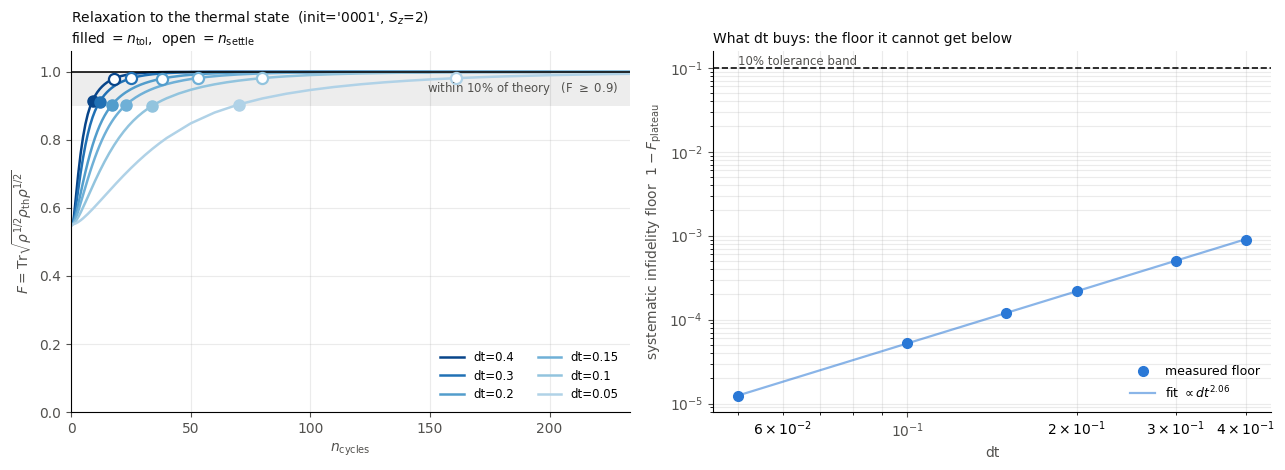

In [29]:
# ---- Plots: relaxation curves + what dt actually buys ----------------------
# dt is an ORDERED quantity, so the curves take a single-hue sequential ramp
# (light = small dt, dark = large dt), not categorical colours.
INK, INK2 = "#0b0b0b", "#52514e"
_d = np.array(dt_list, dtype=float)
_lo, _hi = _d.min(), _d.max()
shade = lambda d: plt.cm.Blues(0.32 + 0.60 * ((d - _lo) / (_hi - _lo)
                                              if _hi > _lo else 1.0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# (1) F vs cycle. Filled marker = n_tol (within tol of the theoretical state);
#     open marker = n_settle (the stricter "stopped improving at this dt").
x_max = 0
for dt in dt_list:
    ns, Fs, plateau, n_tol, floor, n_settle = sweep[dt]
    ax1.plot(ns, Fs, "-", lw=1.8, color=shade(dt), label=f"dt={dt:g}")
    if n_tol is not None:
        ax1.plot(n_tol, Fs[list(ns).index(n_tol)], "o", color=shade(dt), ms=8, zorder=4)
        x_max = max(x_max, n_tol)
    if n_settle is not None:
        ax1.plot(n_settle, Fs[list(ns).index(n_settle)], "o", color=shade(dt),
                 ms=8, mfc="white", mew=1.6, zorder=3)
        x_max = max(x_max, n_settle)

ax1.axhspan(1.0 - tol, 1.0, color="k", alpha=0.07, lw=0)
ax1.axhline(1.0, color=INK, lw=1.2)
ax1.annotate(f"within {tol:.0%} of theory   (F $\\geq$ {1 - tol:g})",
             (0.98, 1.0 - tol / 2), xycoords=("axes fraction", "data"),
             ha="right", va="center", fontsize=8.5, color=INK2)
ax1.set_xlim(0, x_max * 1.45)
ax1.set_ylim(0, 1.06)
ax1.set_xlabel(r"$n_\mathrm{cycles}$", color=INK2)
ax1.set_ylabel(r"$F = \mathrm{Tr}\sqrt{\rho^{1/2}\rho_\mathrm{th}\rho^{1/2}}$",
               color=INK2)
ax1.set_title(f"Relaxation to the thermal state  (init={init_state!r}, $S_z$={Q0})\n"
              r"filled $= n_\mathrm{tol}$,  open $= n_\mathrm{settle}$",
              color=INK, loc="left", fontsize=10)
ax1.legend(frameon=False, fontsize=8.5, loc="lower right", ncol=2)
ax1.grid(alpha=0.25, lw=0.8)
ax1.set_axisbelow(True)

# (2) The only thing dt controls: the systematic infidelity floor. Log-log, with the
#     fitted power law and the tolerance band for scale.
floors = np.array([sweep[dt][4] for dt in dt_list], dtype=float)
ax2.loglog(_d, floors, "o", ms=7, color="#2a78d6", label="measured floor")
if (floors > 0).sum() >= 2:
    k = floors > 0
    slope, inter = np.polyfit(np.log(_d[k]), np.log(floors[k]), 1)
    xf = np.linspace(_d.min(), _d.max(), 50)
    ax2.loglog(xf, np.exp(inter) * xf ** slope, "-", lw=1.6, color="#2a78d6",
               alpha=0.55, label=fr"fit $\propto dt^{{{slope:.2f}}}$")
ax2.axhline(tol, color=INK, lw=1.2, ls="--")
ax2.annotate(f"{tol:.0%} tolerance band", (_d.min(), tol), fontsize=8.5,
             color=INK2, va="bottom", ha="left")
ax2.set_xlabel("dt", color=INK2)
ax2.set_ylabel(r"systematic infidelity floor  $1-F_\mathrm{plateau}$", color=INK2)
ax2.set_title("What dt buys: the floor it cannot get below", color=INK, loc="left",
              fontsize=10)
ax2.legend(frameon=False, fontsize=9, loc="lower right")
ax2.grid(alpha=0.25, lw=0.8, which="both")
ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.tick_params(colors=INK2)
plt.tight_layout()
plt.show()

## Two-qubit Gate Analysis
Where are these two-qubit gates coming from?

Every two-qubit gate in a Trotter step traces back to one Pauli term, in either $H$ or one of the dilation blocks $J_k$. Synthesizing $\exp(-i\theta P)$ for a Pauli string $P$ of **weight** $w$ (its number of non-identity factors) costs a CNOT ladder down and back around a single $R_z$:

$$\mathrm{CNOTs}\big(e^{-i\theta P}\big) = 2(w-1), \qquad w \geq 2,$$

with weight-1 and weight-0 terms free (a single-qubit rotation and a global phase). So the entire cost model is: **list the Pauli terms and histogram their weights.** The cells below do that for each physical piece separately, and check the prediction against an actual transpilation.

**Counting against a hardware ISA, not against the simulator.** `AerSimulator`'s basis includes `rzz`, `rxx` and `ryy`, so transpiling to *it* reports a single "two-qubit gate" where hardware needs two CNOTs — it hides exactly the cost we are trying to measure. We therefore count `cx` after transpiling to a generic superconducting ISA (`cx, rz, sx, x`). The split is exact and additive: the pieces sum to the measured whole-step count, which the cells assert.

In [30]:
# ---- two-qubit gate accounting helpers -------------------------------------
# Count CNOTs against a generic hardware ISA -- NOT the AerSimulator basis, which
# contains rzz/rxx/ryy: there exp(-i.theta.XX) transpiles to ONE 2q instruction and
# the real cost (2 CNOTs) vanishes from the count.
ISA_BASIS = ["cx", "rz", "sx", "x"]
pm_isa = generate_preset_pass_manager(basis_gates=ISA_BASIS, optimization_level=0)


def pauli_weights(op: SparsePauliOp, atol: float = 1e-12) -> dict[int, int]:
    """Histogram {weight: number of Pauli terms} of a SparsePauliOp.

    Weight = number of non-identity factors in the Pauli string. Terms whose
    coefficient simplified to ~0 are skipped."""
    out: dict[int, int] = {}
    for p, c in zip(op.paulis, op.coeffs):
        if abs(c) <= atol:
            continue
        w = int(np.count_nonzero(p.x | p.z))
        out[w] = out.get(w, 0) + 1
    return dict(sorted(out.items()))


def cx_model(op: SparsePauliOp, atol: float = 1e-12) -> int:
    """Predicted CNOTs for ONE LieTrotter rep of exp(-i op t).

    Each Pauli term of weight w becomes a CNOT ladder down and back around one rz:
    2(w-1) CNOTs, and nothing at all for w <= 1. Independent of the evolution time,
    so this is a purely structural count."""
    return sum(n * 2 * (w - 1) for w, n in pauli_weights(op, atol).items() if w >= 2)


def cx_transpiled(op: SparsePauliOp, time: float, reps: int = 1) -> int:
    """Actual CNOTs after synthesizing exp(-i op time) and transpiling to ISA_BASIS."""
    qc = QuantumCircuit(op.num_qubits)
    qc.append(PauliEvolutionGate(op, time=time, synthesis=LieTrotter(reps=reps)),
              range(op.num_qubits))
    return pm_isa.run(qc).count_ops().get("cx", 0)


def schwinger_hamiltonian_parts(L: int, m: float, e: float, a: float,
                                include_shifts: bool = True) -> dict:
    """The same terms get_schwinger_hamiltonian builds, kept as three separate pieces.

    Returns {"H_kin", "H_mass", "H_elec"}. They sum back to H exactly (asserted in
    the next cell), so any cost attributed to a piece is a real share of the total."""
    kin, mass, elec = [], [], []

    kin_coeff = 1.0 / (4.0 * a)
    for i in range(L - 1):
        kin.append(("XX", [i, i + 1], kin_coeff))
        kin.append(("YY", [i, i + 1], kin_coeff))

    for i in range(L):
        coeff = m * ((-1) ** i) / (2.0 * a)
        mass.append(("Z", [i], coeff))
        if include_shifts:
            mass.append(("I", [0], coeff))

    base_I = (a / 2.0) * (e ** 2 / 4.0)
    zz_coeff = (a * e ** 2) / 4.0
    for i in range(1, L + 1):
        C = i % 2
        if include_shifts:
            elec.append(("I", [0], base_I * (i + C)))
        if C == 1:
            for j in range(i):
                elec.append(("Z", [j], zz_coeff))
        for j in range(i):
            for k in range(j + 1, i):
                elec.append(("ZZ", [j, k], zz_coeff))

    mk = lambda terms: SparsePauliOp.from_sparse_list(terms, num_qubits=L).simplify()
    return {"H_kin": mk(kin), "H_mass": mk(mass), "H_elec": mk(elec)}


def lindblad_split(H_op: SparsePauliOp, L: int, a: float, T: float):
    """Split every L(n) = O(n) - (1/4T)[H, O(n)] into its two pieces.

    Returns (full, bare_O, commutator), each a list over sites n. The whole chain
    L(n) -> effective jumps -> J_k is LINEAR in the jump operator, so pushing the two
    pieces through it separately attributes the dilation-block cost between them."""
    Os = [O_n(n, L, a) for n in range(L)]
    comm = [(-(1.0 / (4.0 * T)) * (H_op @ O - O @ H_op)).simplify() for O in Os]
    full = [(O + c).simplify() for O, c in zip(Os, comm)]
    return full, Os, comm

In [31]:
# ---- Breakdown of the two-qubit gates in ONE Trotter step ------------------
L      = 4
a_lat  = 1.0
m_mass = 0.5
e_coup = 0.71
T      = 5.0
dt     = 0.1
D_kind, D0, D_sigma = "delta", 1.0, 1.0

H = get_schwinger_hamiltonian(L, m_mass, e_coup, a_lat)
n_sys = H.num_qubits
parts = schwinger_hamiltonian_parts(L, m_mass, e_coup, a_lat)
assert np.allclose(sum(parts.values()).simplify().to_matrix(), H.to_matrix()), \
    "H_kin + H_mass + H_elec must reproduce H exactly"

# --- 1. the coherent part, exp(-i H dt) -------------------------------------
print("=" * 76)
print("1. Hamiltonian evolution   exp(-i H dt)")
print("=" * 76)
print(f"{'term':9s}{'Pauli weights {w: count}':30s}{'CNOTs':>7}{'transpiled':>12}")
for name, op in parts.items():
    print(f"{name:9s}{str(pauli_weights(op)):30s}{cx_model(op):>7}"
          f"{cx_transpiled(op, dt):>12}")
cx_H = cx_model(H)
print(f"{'H total':9s}{str(pauli_weights(H)):30s}{cx_H:>7}{cx_transpiled(H, dt):>12}")
print("  H_mass is free: every one of its terms is a single Z (weight 1).")

# --- 2. which part of H reaches the jump operators at all -------------------
print()
print("=" * 76)
print("2. What survives into  L(n) = O(n) - (1/4T)[H, O(n)] ?")
print("=" * 76)
for name, op in parts.items():
    nrm = max(float(np.abs((op @ O_n(n, L, a_lat)
                            - O_n(n, L, a_lat) @ op).simplify().coeffs).sum())
              for n in range(L))
    verdict = "commutes -> contributes NOTHING" if nrm < 1e-12 else "drives the correction"
    print(f"  max_n ||[{name}, O(n)]||_1 = {nrm:.2e}   {verdict}")
print("  O(n) ~ Z_n, and H_mass / H_elec are built only from Z and ZZ, so all three")
print("  are diagonal in the same basis. The entire commutator IS the hopping term.")

# --- 3. the dilation blocks, exp(-i J_k sqrt(dt)) ---------------------------
raw_full, raw_O, raw_comm = lindblad_split(H, L, a_lat, T)
assert all(np.allclose(x.to_matrix(), L_n(n=n, H=H, L=L, a=a_lat, T=T).to_matrix())
           for n, x in enumerate(raw_full)), "split must reproduce L_n"

D = D_matrix(L, a_lat, kind=D_kind, D0=D0,
             sigma=(D_sigma if D_kind == "gaussian" else None))
eff_full = diagonalized_lindblad_ops(raw_full, D, a_lat)
eff_O    = diagonalized_lindblad_ops(raw_O,    D, a_lat)
eff_comm = diagonalized_lindblad_ops(raw_comm, D, a_lat)

print()
print("=" * 76)
print("3. Dilation blocks   exp(-i J_k sqrt(dt)),   J_k = |1><0| (x) L_k + h.c.")
print("=" * 76)
print(f"{'block':7s}{'L_k weights':22s}{'J_k weights':24s}{'CNOTs':>7}{'transp':>8}"
      f"{'from O':>8}{'from [H,O]':>12}")
cx_blocks = cx_from_O = cx_from_comm = ancilla_tax = 0
for k, (Lf, Lo, Lc) in enumerate(zip(eff_full, eff_O, eff_comm), start=1):
    Jf = build_J_operator([Lf], n_sys=n_sys)
    Jo = build_J_operator([Lo], n_sys=n_sys)
    Jc = build_J_operator([Lc], n_sys=n_sys)
    print(f"{'J_' + str(k):7s}{str(pauli_weights(Lf)):22s}{str(pauli_weights(Jf)):24s}"
          f"{cx_model(Jf):>7}{cx_transpiled(Jf, np.sqrt(dt)):>8}"
          f"{cx_model(Jo):>8}{cx_model(Jc):>12}")
    cx_blocks     += cx_model(Jf)
    cx_from_O     += cx_model(Jo)
    cx_from_comm  += cx_model(Jc)
    ancilla_tax   += cx_model(Jf) - cx_model(Lf)
print(f"{'total':53s}{cx_blocks:>7}{'':8}{cx_from_O:>8}{cx_from_comm:>12}")

mix = cx_blocks - (cx_from_O + cx_from_comm)
if mix:
    print(f"  (!) {mix} CNOTs are not attributable: the two pieces share Pauli strings")
    print("      and partially cancel under simplify(); treat the split as approximate.")
print(f"  Dilating onto the ancilla lifts EVERY Pauli term of L_k by one qubit")
print(f"  (weight w -> w+1, so +2 CNOTs per term): {ancilla_tax} of these {cx_blocks}")
print(f"  CNOTs are that ancilla leg alone.")

# --- 4. the whole step ------------------------------------------------------
step = build_single_ancilla_circuit(H_op=H, eff_L_ops=eff_full, n_sys=n_sys,
                                    dt=dt, n_steps=1)
cx_step = pm_isa.run(step).count_ops().get("cx", 0)

sources = {
    "[H_kin, O(n)] inside J_k":    cx_from_comm,
    "H_elec (ZZ) in exp(-iH dt)":  cx_model(parts["H_elec"]),
    "H_kin (XX+YY) in exp(-iH dt)": cx_model(parts["H_kin"]),
    "bare O(n) inside J_k":        cx_from_O,
    "H_mass (Z) in exp(-iH dt)":   cx_model(parts["H_mass"]),
}
print()
print("=" * 76)
print(f"4. One Trotter step: {cx_step} CNOTs measured, {cx_H + cx_blocks} predicted")
print("=" * 76)
for name, v in sorted(sources.items(), key=lambda kv: -kv[1]):
    print(f"  {name:32s}{v:>5}{100 * v / cx_step:>8.1f}%")
assert cx_step == cx_H + cx_blocks, "per-block prediction must match the built circuit"

kin_direct = cx_model(parts["H_kin"])
kin_total = kin_direct + cx_from_comm
print(f"\n  The hopping term XX+YY drives {kin_total}/{cx_step} = "
      f"{100 * kin_total / cx_step:.0f}% of the step:")
print(f"    {kin_direct:>4} directly, in exp(-iH dt)")
print(f"    {cx_from_comm:>4} indirectly, through [H, O(n)] inside the jump operators")

1. Hamiltonian evolution   exp(-i H dt)
term     Pauli weights {w: count}        CNOTs  transpiled
H_kin    {2: 6}                             12          12
H_mass   {1: 4}                              0           0
H_elec   {0: 1, 1: 3, 2: 6}                 12          12
H total  {0: 1, 1: 4, 2: 12}                24          24
  H_mass is free: every one of its terms is a single Z (weight 1).

2. What survives into  L(n) = O(n) - (1/4T)[H, O(n)] ?
  max_n ||[H_kin, O(n)]||_1 = 1.00e+00   drives the correction
  max_n ||[H_mass, O(n)]||_1 = 0.00e+00   commutes -> contributes NOTHING
  max_n ||[H_elec, O(n)]||_1 = 0.00e+00   commutes -> contributes NOTHING
  O(n) ~ Z_n, and H_mass / H_elec are built only from Z and ZZ, so all three
  are diagonal in the same basis. The entire commutator IS the hopping term.

3. Dilation blocks   exp(-i J_k sqrt(dt)),   J_k = |1><0| (x) L_k + h.c.
block  L_k weights           J_k weights               CNOTs  transp  from O  from [H,O]
J_1    {0: 1, 

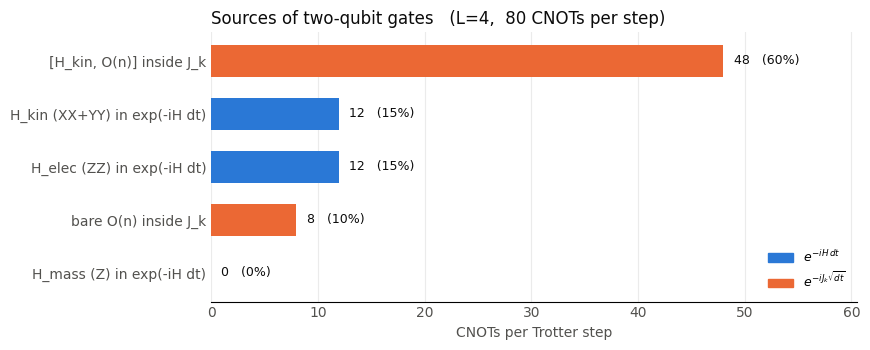

In [32]:
# ---- Chart: where the CNOTs come from --------------------------------------
# Categorical hues in fixed slot order; colour = which block of the step the cost
# sits in. Every bar is directly labelled, so identity is never colour-alone.
C_H, C_J = "#2a78d6", "#eb6834"          # slot 1 blue, slot 2 orange
INK, INK2 = "#0b0b0b", "#52514e"

block_of = {
    "[H_kin, O(n)] inside J_k":     "J",
    "bare O(n) inside J_k":         "J",
    "H_kin (XX+YY) in exp(-iH dt)": "H",
    "H_elec (ZZ) in exp(-iH dt)":   "H",
    "H_mass (Z) in exp(-iH dt)":    "H",
}

items = sorted(sources.items(), key=lambda kv: kv[1])      # ascending -> biggest on top
labels = [k for k, _ in items]
vals = [v for _, v in items]

fig, ax = plt.subplots(figsize=(8.8, 3.6))
ax.barh(labels, vals, height=0.62,
        color=[C_H if block_of[k] == "H" else C_J for k in labels])
for y, v in enumerate(vals):
    ax.text(v + max(vals) * 0.02, y, f"{v}   ({100 * v / cx_step:.0f}%)",
            va="center", fontsize=9, color=INK)

ax.set_xlim(0, max(vals) * 1.26)
ax.set_xlabel("CNOTs per Trotter step", color=INK2)
ax.set_title(f"Sources of two-qubit gates   (L={L},  {cx_step} CNOTs per step)",
             color=INK, loc="left")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C_H),
                   plt.Rectangle((0, 0), 1, 1, color=C_J)],
          labels=[r"$e^{-iH\,dt}$", r"$e^{-iJ_k\sqrt{dt}}$"],
          frameon=False, loc="lower right", fontsize=9)
ax.xaxis.grid(True, alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2, length=0)
plt.tight_layout()
plt.show()

   L   J_k: [H_kin, O(n)]          H_elec (ZZ)       J_k: bare O(n)        H_kin (XX+YY)  step total
----------------------------------------------------------------------------------------------------
   4                   48                   12                    8                   12          80
   6                   80                   30                   12                   20         142
   8                  112                   56                   16                   28         212
  10                  144                   90                   20                   36         290
  12                  176                  132                   24                   44         376

  H_elec is the only quadratic source: E_n^2 puts a ZZ term on every PAIR of
  sites, 2 CNOTs each -> L(L-1). Everything else is linear in L, because the
  hopping term and [H_kin, O(n)] only ever couple neighbours.
  The jump operators dominate at small L; H_elec overtakes all of them toget

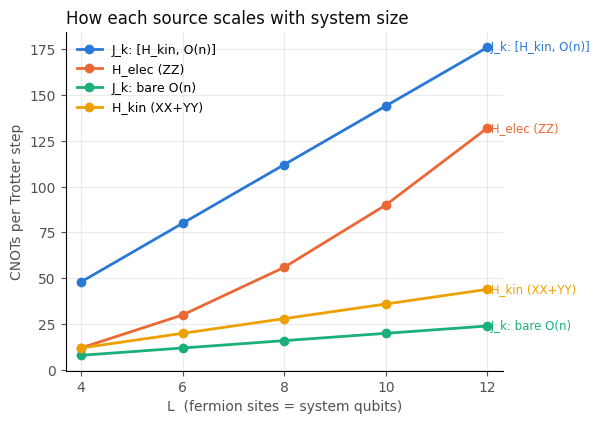

In [33]:
# ---- How each source scales with system size -------------------------------
# Pure structural counts (cx_model) -- no simulation and no transpilation, so this
# stays cheap even out to L = 32.
def cx_sources(Ls: int) -> dict:
    """Every CNOT source at system size Ls, counted structurally."""
    Hs = get_schwinger_hamiltonian(Ls, m_mass, e_coup, a_lat)
    ps = schwinger_hamiltonian_parts(Ls, m_mass, e_coup, a_lat)
    Ds = D_matrix(Ls, a_lat, kind=D_kind, D0=D0,
                  sigma=(D_sigma if D_kind == "gaussian" else None))
    rf, ro, rc = lindblad_split(Hs, Ls, a_lat, T)
    blk = lambda raw: sum(cx_model(build_J_operator([x], n_sys=Ls))
                          for x in diagonalized_lindblad_ops(raw, Ds, a_lat))
    blocks = blk(rf)
    return {"L": Ls,
            "H_kin (XX+YY)": cx_model(ps["H_kin"]),
            "H_elec (ZZ)": cx_model(ps["H_elec"]),
            "J_k: bare O(n)": blk(ro),
            "J_k: [H_kin, O(n)]": blk(rc),
            "blocks": blocks,
            "step total": cx_model(Hs) + blocks}


L_list = [4, 6, 8, 10, 12]
rows = [cx_sources(Ls) for Ls in L_list]

SERIES = ["J_k: [H_kin, O(n)]", "H_elec (ZZ)", "J_k: bare O(n)", "H_kin (XX+YY)"]
COLS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]     # slots 1-4, fixed order

hdr = f"{'L':>4}" + "".join(f"{s:>21}" for s in SERIES) + f"{'step total':>12}"
print(hdr)
print("-" * len(hdr))
for r in rows:
    print(f"{r['L']:>4}" + "".join(f"{r[s]:>21}" for s in SERIES)
          + f"{r['step total']:>12}")

# Where does the quadratic electric term overtake ALL the dilation blocks together?
cross = next((Ls for Ls in range(4, 33, 2)
              if cx_sources(Ls)["H_elec (ZZ)"] > cx_sources(Ls)["blocks"]), None)

print()
print("  H_elec is the only quadratic source: E_n^2 puts a ZZ term on every PAIR of")
print("  sites, 2 CNOTs each -> L(L-1). Everything else is linear in L, because the")
print("  hopping term and [H_kin, O(n)] only ever couple neighbours.")
print(f"  The jump operators dominate at small L; H_elec overtakes all of them together"
      + (f" at L = {cross}." if cross else " somewhere beyond L = 32."))

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for name, col in zip(SERIES, COLS):
    y = [r[name] for r in rows]
    ax.plot(L_list, y, "-o", color=col, lw=2, ms=6, label=name)
    ax.annotate(f" {name}", (L_list[-1], y[-1]), color=col, fontsize=8.5,
                va="center", ha="left", annotation_clip=False)

ax.set_xlabel("L  (fermion sites = system qubits)", color=INK2)
ax.set_ylabel("CNOTs per Trotter step", color=INK2)
ax.set_title("How each source scales with system size", color=INK, loc="left")
ax.set_xticks(L_list)
ax.set_xlim(L_list[0] - 0.3, L_list[-1] + 0.3)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.grid(True, alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK2)
fig.subplots_adjust(right=0.70)
plt.show()

## Things we can use to gauge how this quantum circuit behaves in different limits: g and L